Scala 3 is used with Almond kernel for Jupyter. It is possible to run it inside docker container using eclipse-temurin:21-jre-jammy. Template provided.

# Libraries and core functions

In [ ]:
import $ivy.`org.jfree:jfreechart:1.5.6`
import $ivy.`org.apache.commons:commons-math3:3.6.1`

// For reading files
import scala.io.Source

// For collections
import scala.collection.mutable
import scala.math.pow

// For calculations
import org.apache.commons.math3.linear.{ LUDecomposition, MatrixUtils, RealMatrix, DiagonalMatrix, SingularValueDecomposition, ArrayRealVector, Array2DRowRealMatrix}

// For display
import org.jfree.chart.plot.PlotOrientation
import org.jfree.chart.plot.XYPlot
import org.jfree.chart.renderer.xy.XYItemRenderer
import org.jfree.chart.ChartFactory
import org.jfree.chart.JFreeChart
import javax.imageio.ImageIO
import almond.display.Image
import java.io.ByteArrayOutputStream
import org.jfree.data.xy.{DefaultXYDataset, XYSeries, XYSeriesCollection }
import org.jfree.chart.renderer.xy.XYLineAndShapeRenderer
import java.awt.image.BufferedImage
import java.awt.geom.{Ellipse2D, Rectangle2D}
import java.awt.{Color, Font, Shape, BasicStroke, Polygon, Stroke }

import $ivy.$                           

import $ivy.$                                       

// For reading files

import scala.io.Source

// For collections

import scala.collection.mutable

import scala.math.pow

// For calculations

import org.apache.commons.math3.linear.{ LUDecomposition, MatrixUtils, RealMatrix, DiagonalMatrix, SingularValueDecomposition, ArrayRealVector, Array2DRowRealMatrix}

// For display

import org.jfree.chart.plot.PlotOrientation

import org.jfree.chart.plot.XYPlot

import org.jfree.chart.renderer.xy.XYItemRenderer

import org.jfree.chart.ChartFactory

import org.jfree.chart.JFreeChart

import javax.imageio.ImageIO

import almond.display.Image

import java.io.ByteArrayOutputStream

import org.jfree.data.xy.{DefaultXYDataset, XYSeries, XYSeriesCollection }

import org.jfree.chart.renderer.xy.XYLineAndShapeRenderer

import java.awt.image.BufferedImage

import java.awt.geom.{Ellipse2D, Rectangle2D}

import java.awt.{Color, Font, Shape, BasicStroke, Polygon,

## Display

In [2]:
def circle(r: Double): Shape = new Ellipse2D.Double(-r, -r, 2 * r, 2 * r)
def square(r: Double): Shape = new Rectangle2D.Double(-r, -r, 2 * r, 2 * r)
def triangle(r: Double): Shape = {
  val ri = r.toInt
  new Polygon(Array(0, ri, -ri), Array(-ri, ri, ri), ri)
}

def solid(width: Float = 2f): Stroke = new BasicStroke(width, BasicStroke.CAP_ROUND, BasicStroke.JOIN_ROUND)
def dashed(width: Float = 2f, dash: Float = 8f, gap: Float = 4f): Stroke = 
  new BasicStroke(width, BasicStroke.CAP_ROUND, BasicStroke.JOIN_ROUND, 0f, Array(dash, gap), 0f)
def dotted(width: Float = 2f): Stroke = 
  new BasicStroke(width, BasicStroke.CAP_ROUND, BasicStroke.JOIN_ROUND, 0f, Array(2f, 4f), 0f)

enum DrawMode:
  case LinesOnly, PointsOnly, LinesAndPoints

case class SeriesStyle(
  color: Color = Color.BLACK,
  shape: Shape = circle(4),
  lineWidth: Float = 2f,
  stroke: Stroke = solid(2f),
  drawMode: DrawMode = DrawMode.LinesAndPoints,
  shapeFilled: Boolean = true,
  // Optional: per-series renderer hints (e.g., for transparency)
  rendererHints: Map[AnyRef, AnyRef] = Map.empty
)

def display(
  chart: JFreeChart,
  styles: Map[String, SeriesStyle] = Map.empty,
  defaultStyle: SeriesStyle = SeriesStyle(), // fallback for unstyled series
  backgroundColor: Color = Color.WHITE,
  gridlineColor: Color = new Color(220, 220, 220, 120),
  width: Int = 1000,
  height: Int = 600
) = {
  val plot = chart.getPlot().asInstanceOf[XYPlot]
  val renderer = plot.getRenderer().asInstanceOf[XYLineAndShapeRenderer]
  val dataset = plot.getDataset().asInstanceOf[XYSeriesCollection]

  // 🔹 Global styling
  plot.setBackgroundPaint(backgroundColor)
  plot.setDomainGridlinePaint(gridlineColor)
  plot.setRangeGridlinePaint(gridlineColor)

  // Improve fonts
  val axisFont = new Font("Arial", Font.PLAIN, 12)
  val labelFont = new Font("Arial", Font.BOLD, 14)
  plot.getDomainAxis().setLabelFont(labelFont)
  plot.getRangeAxis().setLabelFont(labelFont)
  plot.getDomainAxis().setTickLabelFont(axisFont)
  plot.getRangeAxis().setTickLabelFont(axisFont)
  chart.getTitle().setFont(new Font("Arial", Font.BOLD, 16))

  // 🔹 Apply per-series styles by NAME
  val seriesCount = dataset.getSeriesCount()
  for (i <- 0 until seriesCount) {
    val series = dataset.getSeries(i)
    val seriesName = series.getKey.toString
    val style = styles.getOrElse(seriesName, defaultStyle)

    // Set visual properties
    renderer.setSeriesPaint(i, style.color)
    renderer.setSeriesShape(i, style.shape)
    renderer.setSeriesStroke(i, style.stroke)
    renderer.setSeriesShapesFilled(i, style.shapeFilled)

    // Draw mode logic
    style.drawMode match {
      case DrawMode.LinesOnly       => renderer.setSeriesLinesVisible(i, true);  renderer.setSeriesShapesVisible(i, false)
      case DrawMode.PointsOnly      => renderer.setSeriesLinesVisible(i, false); renderer.setSeriesShapesVisible(i, true)
      case DrawMode.LinesAndPoints  => renderer.setSeriesLinesVisible(i, true);  renderer.setSeriesShapesVisible(i, true)
    }
  }

  // 🔹 Render image
  val img = chart.createBufferedImage(width, height, BufferedImage.TYPE_INT_ARGB, null)
  val baos = new ByteArrayOutputStream()
  ImageIO.write(img, "png", baos)
  almond.display.Image(baos.toByteArray)
}

defined function circle
defined function square
defined function triangle
defined function solid
defined function dashed
defined function dotted
defined class DrawMode
defined class SeriesStyle
defined function display

# Theme 1

## Lagrange task

Интерполяция по Лагранжу

$$
P(x)=\sum\limits_{i=0}^ny_i\prod\limits_{j\neq i}\frac{x-x_i}{x_i-x_j}
$$

Где получили: это просто сложение табличных значений функции, умноженных на символы кронекера. Когда x равен одному из табличных аргументов, значение это суммы становится равным одному из табличных значений.

Сначала вычисляются коэффициенты x, xs
Далее вычисляется значение с помощью коэффициентов и ys 

In [87]:
def lagrangeCoeffs(x: Double, xs: Vector[Double]): Vector[Double] = {
  val n = xs.length;
  (0 until n).map {i => 
    (0 until n).filter(_ != i).map { j =>
      (x - xs(j)) / (xs(i) - xs(j))
    }.product
}.toVector
}

def lagrangeInterpolant(c: Vector[Double], ys: Vector[Double]):
                       Double = {
  val n = c.length
  (0 until n).map { i => ys(i) * c(i) }.sum
}

defined function lagrangeCoeffs
defined function lagrangeInterpolant

In [88]:
val x = 1.5
val xs = Vector(0.0, 1.0, 2.0)
val ys = Vector(1.0, 3.0, 2.0)

val c = lagrangeCoeffs(x, xs)
val p = lagrangeInterpolant(c, ys)

x: Double = 1.5
xs: Vector[Double] = Vector(0.0, 1.0, 2.0)
ys: Vector[Double] = Vector(1.0, 3.0, 2.0)
c: Vector[Double] = Vector(-0.125, 0.75, 0.375)
p: Double = 2.875

Let's combine it into simple function for simple use

In [89]:
def lagrange(xs: Vector[Double], ys: Vector[Double]) (x: Double): Double = {
  val c = lagrangeCoeffs(x, xs)
  lagrangeInterpolant(c, ys)
}

defined function lagrange

In [90]:
val p = lagrange(xs, ys)
p(1.5)

p: Double => Double = ammonite.$sess.cmd90$Helper$$Lambda$5691/691638239@67d41983
res90_1: Double = 2.875

## Display Technics
Try to find visual libraries for Scala 3 Almond Jupyter kernel

### Java charts test

In [91]:
val x = Array[Double](1,2,3,4,5,6,7,8,9,10)
val y = x.map(_*2)
val dataset = new DefaultXYDataset
dataset.addSeries("Series 1",Array(x,y))

val chart = ChartFactory.createScatterPlot(
    "Plot",
    "X Label",
    "Y Label",
    dataset,
    PlotOrientation.HORIZONTAL,
    true,true,false
  )

x: Array[Double] = Array(1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0)
y: Array[Double] = Array(2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0)
dataset: DefaultXYDataset = org.jfree.data.xy.DefaultXYDataset@23af330
chart: JFreeChart = org.jfree.chart.JFreeChart@c3ba5675

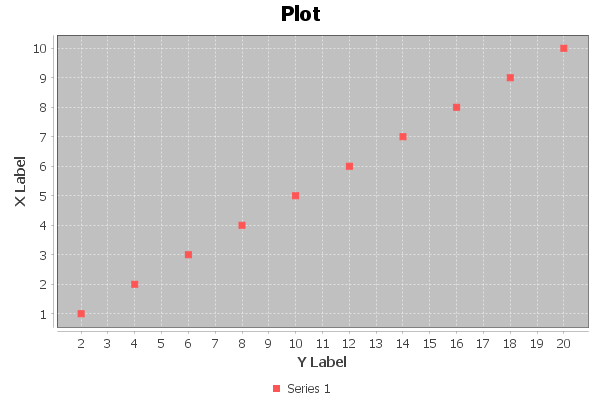

defined function displayOld

In [92]:
def displayOld(chart: JFreeChart, width: Int = 600, height: Int = 400) = {
  val img = chart.createBufferedImage(width, height)
  val baos = new ByteArrayOutputStream()
  ImageIO.write(img, "png", baos)
  almond.display.Image(baos.toByteArray)
}

displayOld(chart)

### Charts with style

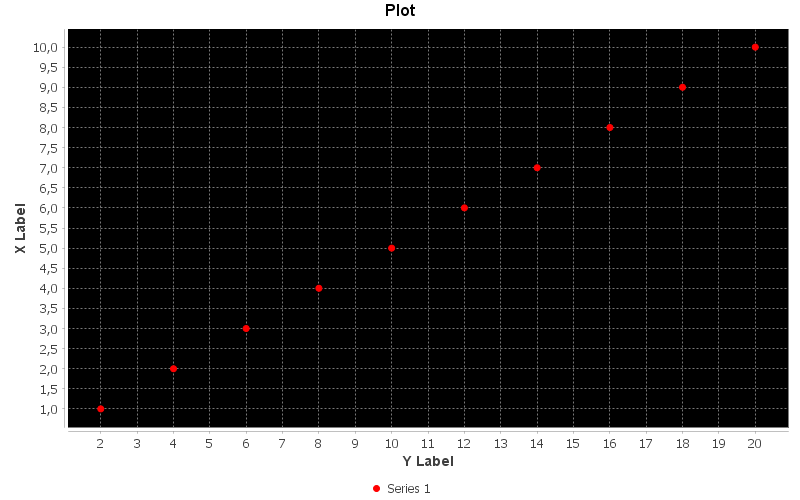

defined class ChartStyle
defined function displayOldStyle
x: Array[Double] = Array(1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0)
y: Array[Double] = Array(2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0)
dataset: DefaultXYDataset = org.jfree.data.xy.DefaultXYDataset@f814c61a
chart: JFreeChart = org.jfree.chart.JFreeChart@20710bb3

In [93]:
// Styling configuration case class
case class ChartStyle(
  backgroundColor: Color = Color.BLACK,
  gridlineColor: Color = new Color(240, 240, 240),
  seriesColor: Color = Color.RED,
  markerSize: Float = 4.0f,
  markerShape: Shape = new java.awt.geom.Ellipse2D.Double(-3, -3, 6, 6),
  axisLabelFont: Font = new Font("Arial", Font.BOLD, 14),
  titleFont: Font = new Font("Arial", Font.BOLD, 16)
)

def displayOldStyle(chart: JFreeChart, style: ChartStyle = ChartStyle(), width: Int = 800, height: Int = 500) = {
  // Style
  val plot = chart.getPlot().asInstanceOf[XYPlot]
  plot.setBackgroundPaint(style.backgroundColor)
  plot.setDomainGridlinePaint(style.gridlineColor)
  plot.setRangeGridlinePaint(style.gridlineColor)
  val renderer = plot.getRenderer().asInstanceOf[XYItemRenderer]
  renderer.setSeriesPaint(0, style.seriesColor)
  renderer.setSeriesShape(0, style.markerShape)
  renderer.setSeriesItemLabelsVisible(0, false)
  chart.getTitle().setFont(style.titleFont)
  plot.getDomainAxis().setLabelFont(style.axisLabelFont)
  plot.getRangeAxis().setLabelFont(style.axisLabelFont)

  // Image
  val img = chart.createBufferedImage(width, height)
  val baos = new ByteArrayOutputStream()
  ImageIO.write(img, "png", baos)
  almond.display.Image(baos.toByteArray)
}

val x = Array[Double](1,2,3,4,5,6,7,8,9,10)
val y = x.map(_*2)
val dataset = new DefaultXYDataset
dataset.addSeries("Series 1",Array(x,y))

val chart = ChartFactory.createScatterPlot(
    "Plot",
    "X Label",
    "Y Label",
    dataset,
    PlotOrientation.HORIZONTAL,
    true,true,false
  )

displayOldStyle(chart)

### Multiple series

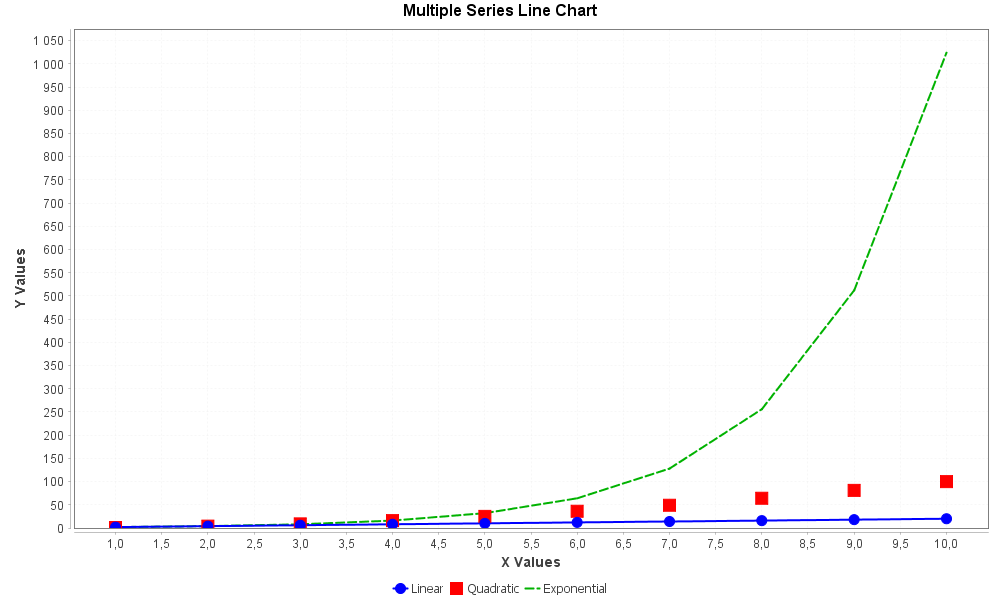

dataset: XYSeriesCollection = org.jfree.data.xy.XYSeriesCollection@91c51a22
series1: XYSeries = org.jfree.data.xy.XYSeries@c6ab1f8b
series2: XYSeries = org.jfree.data.xy.XYSeries@899eb882
series3: XYSeries = org.jfree.data.xy.XYSeries@4c0b07eb
chart: JFreeChart = org.jfree.chart.JFreeChart@633beb1f

In [94]:
val dataset = new XYSeriesCollection()

val series1 = new XYSeries("Linear")
(1 to 10).foreach(i => series1.add(i, i * 2))
dataset.addSeries(series1)

val series2 = new XYSeries("Quadratic")
(1 to 10).foreach(i => series2.add(i, i * i))
dataset.addSeries(series2)

val series3 = new XYSeries("Exponential")
(1 to 10).foreach(i => series3.add(i, math.pow(2, i)))
dataset.addSeries(series3)

val chart = ChartFactory.createXYLineChart(
  "Multiple Series Line Chart",
  "X Values",
  "Y Values",
  dataset,
  PlotOrientation.VERTICAL,
  true,
  true,
  false
)

display(chart,
  styles = Map(
    "Linear"      -> SeriesStyle(color = Color.BLUE,      drawMode = DrawMode.LinesAndPoints, shape = circle(5)),
    "Quadratic"   -> SeriesStyle(color = Color.RED,       drawMode = DrawMode.PointsOnly,     shape = square(6)),
    "Exponential" -> SeriesStyle(color = Color.GREEN.darker(), drawMode = DrawMode.LinesOnly,  stroke = dashed(2f))
  )
)

## Lagrange showdown

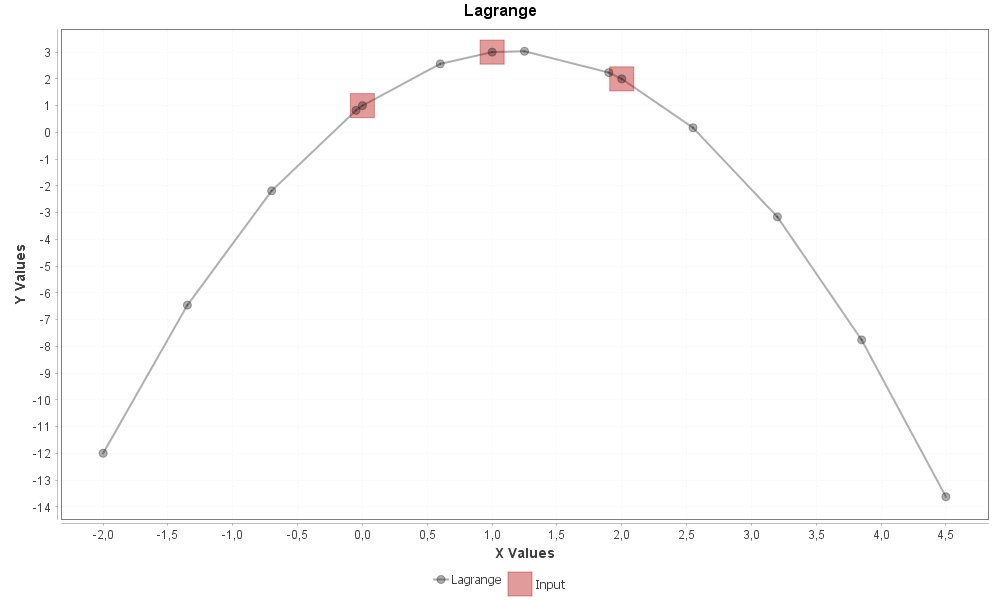

divs: Int = 10
a: Double = -2.0
b: Double = 4.5
h: Double = 0.65
dataset: XYSeriesCollection = org.jfree.data.xy.XYSeriesCollection@6ea930a3
series1: XYSeries = org.jfree.data.xy.XYSeries@32e71e59
series2: XYSeries = org.jfree.data.xy.XYSeries@718ca2cc
chart: JFreeChart = org.jfree.chart.JFreeChart@89353653

In [ ]:
val divs = 10
val a = -2.0
val b = 4.5
val h = (b - a) / divs

val dataset = new XYSeriesCollection()

val series1 = new XYSeries("Lagrange")
(0 to divs).foreach(i => series1.add(a + i * h, p(a + i * h)))

val series2 = new XYSeries("Input")
(0 to xs.length - 1).foreach(i => { 
  val x = xs(i)
  series2.add(x, ys(i))
  series1.add(x, p(x))
  })
dataset.addSeries(series1)
dataset.addSeries(series2)

val chart = ChartFactory.createXYLineChart(
  "Lagrange",
  "X Values",
  "Y Values",
  dataset,
  PlotOrientation.VERTICAL,  // Use VERTICAL for standard line charts
  true,   // legend
  true,   // tooltips
  false   // URLs
)

display(chart,
  styles = Map(
    "Lagrange"      -> SeriesStyle(color = new Color(0,0,0,80),      drawMode = DrawMode.LinesAndPoints, shape = circle(4)),
    "Input"   -> SeriesStyle(color = new Color(180,0,0,100),       drawMode = DrawMode.PointsOnly,     shape = square(12)),
  )
)

## Regression
(Why do I use Scala?)

### Regression theory

Задача линейной регрессии ставится следующим образом:

Есть объекты X и целевые значения Y, а также признаки - функции от объектов, дающие вещественные значения. Задача состоит в нахождении функции - алгоритма, по которому можно аппроксимировать другие значения с теми же признаками. 

Тогда задачей линейной регрессии становится поиск весов - таких, что функция вида

$$
a(x) = w_0 + \sum\limits_{k=1}^n w_k f_k(x)
$$

даёт наилучшую аппроксимацию на обучающем наборе I. Задача аппроксимации может иметь вид минимизации функции потерь:

$$
L^I(a) = \sum\limits_{i=1}^m L(a,x^i) \rarr min
$$

при этом конкретная функция потерь может иметь вид

$$
L(a,x) = (a(x) - y_x)^2
$$

где

$$
y_x - реальное \ искомое \ значение \ из \ Y \ для \ взятого \ объекта \ x
$$

Эту задачу можно решить аналитически, взяв градиент и приравняв к нулю. Но перед этим унифицируем веса $w_0$ и $w_k$, введя нулевой признак $f_0 == 1$. Тогда получим:

$$
\frac{\partial a(x_i)}{\partial w_k} = f_k(x_i)
$$

$$
\frac{\partial L^I}{\partial w_k} = 2 \sum_{i=1}^m (a(x_i) - y_i) f_k(x_i) = 0
$$

$$
\sum_{i=1}^m (\sum\limits_{k=0}^n w_k f_k(x_i) - y_i) f_j(x_i) = 0, \quad j = 0\dots n \ - \ \text{замена внешнего индекса}
$$

$$
\sum_{i=1}^m \left ( f_j(x_i) \sum\limits_{k=0}^n w_k f_k(x_i) - f_j(x_i) y_i \right )  = 0
$$

$$
\sum\limits_{k=0}^n w_k \sum_{i=1}^m f_k(x_i) f_j(x_i)  = \sum_{i=1}^m y_i f_j(x_i)
$$

$$
\sum\limits_{k=0}^n w_k F_k^\top F_j  = Y^\top f_j
$$

Переходя к матричному виду через $F_k^\top F_j = (X^\top X)_{kj}$, получим:

$$
X^\top X w = X^\top Y
$$

Если матрица обратима, то

$$
w = (X^\top X)^{-1} X^\top Y
$$

Стоит сказать, что точность полученного решения всё ещё под сомнением. Количество, линейная независимость и способность к порождению зависимости данных признаков под вопросом.

Минимум достигается всегда, но может не быть 0.

0 - момент переобучения, когда модель превращается в интерполяцию. Модель, которая запоминает шум и не способна хорошо предсказывать будущие значения. Гораздо лучше, когда минимум близок, но отличен от нуля.

Обычно в случае, когда точное решение найти нельзя, используется метод градиентного спуска SGD.

### Regression model

Создадим модель непосредственно в Scala 3. Начнём с признаков (features):

В данном примере, есть бинарные, целые и вещественные данные, которые можно интерпретировать отдельно друг от друга.

Объединим это всё в модель.

In [35]:
// Основа признаков объектов - интерфейс
sealed trait Feature {
  def columnIdx: Int
  def weightIdx: Int
}

// Сами признаки
object Feature {
  case class Scalar(columnIdx: Int, weightIdx: Int) extends Feature
  case class Scaled(columnIdx: Int, weightIdx: Int, scale: Double) extends Feature
  case class Power(columnIdx: Int, weightIdx: Int, p: Double) extends Feature
  case class Categorical(columnIdx: Int, weightIdx: Int, encoding: Map[String, Double]) extends Feature
}

// Обучаемая модель линейной регрессии
class TrainableLinearRegressionModel private (
  private var bias: Double,
  private var weights: Vector[Double],
  private var features: Vector[Feature]
) {
  // В начале признаки помещаются в неотсортированный массив
  private val unsortedFeatures: mutable.ArrayBuffer[Feature] = mutable.ArrayBuffer.empty

  // f(x) = (значение в ячейке)
  def addScalarFeature(columnIdx: Int): this.type = {
    val wid = weights.length
    weights = weights :+ 0.0
    unsortedFeatures += Feature.Scalar(columnIdx, wid)
    this
  }

  // f(x) = c * (значение в ячейке)
  def addScaledFeature(columnIdx: Int, scale: Double): this.type = {
    val wid = weights.length
    weights = weights :+ 0.0
    unsortedFeatures += Feature.Scaled(columnIdx, wid, scale)
    this
  }

  // f(x) = (значение в ячейке)^p
  def addPowerFeature(columnIdx: Int, p: Double): this.type = {
    val wid = weights.length
    weights = weights :+ 0.0
    unsortedFeatures += Feature.Power(columnIdx, wid, p)
    this
  }

  // f(x) = значения_категории[текст в ячейке]
  def addCategoricalFeature(columnIdx: Int, encoding: Map[String, Double]): this.type = {
    val wid = weights.length
    weights = weights :+ 0.0
    unsortedFeatures += Feature.Categorical(columnIdx, wid, encoding)
    this
  }

  // Достраиваем для конечного применения или обучения
  def build(): this.type = {
    features = unsortedFeatures.sortBy(_.columnIdx).toVector
    unsortedFeatures.clear()
    this
  }

  def fit(rows: Array[Array[String]], targetColIdx: Int, lambda: Double, polyDegree: Int = 0): this.type = {
    // require(features.nonEmpty, "At least one feature must be added before fitting")

    if (!features.nonEmpty) {
      return this
    }
    val m = rows.length
    val p = 1 + weights.length // 1 для bias, остальное для весов

    if (m == 0) throw new IllegalArgumentException("No training data provided")

    // Строим матрицу X (m × p) и вектор y
    val Xdata = Array.ofDim[Double](m, p)
    val ydata = Array.ofDim[Double](m)

    for (i <- rows.indices) {
      val row = rows(i)
      Xdata(i)(0) = 1.0 // столбец для bias

      for (j <- features.indices) {
        val feat = features(j)
        val value = feat match {
          case Feature.Scalar(colIdx, _) =>
            parseOrZero(row(colIdx))
          case Feature.Scaled(colIdx, _, scale) =>
            parseOrZero(row(colIdx)) * scale
          case Feature.Power(colIdx, _, p) =>
            math.pow(parseOrZero(row(colIdx)), p)
          case Feature.Categorical(colIdx, _, enc) =>
            enc.getOrElse(row(colIdx), 0.0)
        }
        Xdata(i)(j + 1) = value
      }

      ydata(i) = parseOrZero(row(targetColIdx))
    }

    // Конвертируем в матрицы Commons Math
    val X = new Array2DRowRealMatrix(Xdata)
    val y = new ArrayRealVector(ydata)

    val effectiveLambda = 
      if (polyDegree > 0) math.max(lambda, 0.1 * polyDegree)
      else lambda

    val XTX = X.transpose.multiply(X)
    val identity = MatrixUtils.createRealIdentityMatrix(XTX.getRowDimension)
    val regularized = XTX.add(identity.scalarMultiply(effectiveLambda))
  
    // Решаем: (XᵀX + λI) w = Xᵀ y
    val solver = new LUDecomposition(regularized).getSolver
    val wVector = solver.solve(X.transpose.operate(y))

    // Устанавливаем параметры модели
    bias = wVector.getEntry(0)
    for (j <- weights.indices) {
      setWeight(j, wVector.getEntry(j + 1))
    }

    this
  }

  def getBias: Double = bias
  def getWeights: Vector[Double] = weights
  def getFeatures(): Vector[Feature] = features
  def setBias(b: Double): Unit = bias = b
  def setWeight(i: Int, v: Double): Unit = weights = weights.updated(i, v)
  def updateWeight(i: Int, delta: Double): Unit = weights = weights.updated(i, weights(i) + delta)

  // function a(x)
  def predict(row: Vector[String]): Double = {
    var result = bias
    val n = row.length

    var i = 0
    while (i < features.length) {
      val feat = features(i)
      if (feat.columnIdx < n) {
        feat match {
          case Feature.Scalar(_, wid) =>
            result += weights(wid) * parseOrZero(row(feat.columnIdx))
          case Feature.Scaled(_, wid, scale) =>
            result += weights(wid) * scale * parseOrZero(row(feat.columnIdx))
          case Feature.Power(_, wid, p) =>
            result += weights(wid) * math.pow(parseOrZero(row(feat.columnIdx)), p)
          case Feature.Categorical(_, wid, enc) =>
            val str = row(feat.columnIdx)
            result += weights(wid) * enc.getOrElse(str, 0.0)
        }
      }
      i += 1
    }
    result
  }

  // Замораживаем модель для оптимизаций неизменностей
  def freeze(): FrozenLinearRegressionModel =
    FrozenLinearRegressionModel(bias, weights, features)

  // Вспомогательная функция
  private def parseOrZero(s: String): Double =
    if (s.isEmpty) 0.0 else try s.toDouble catch { case _: Throwable => 0.0 }
}

// Объект - компаньон - статика
object TrainableLinearRegressionModel {
  def apply(initialBias: Double = 0.0): TrainableLinearRegressionModel =
    new TrainableLinearRegressionModel(initialBias, Vector.empty, Vector.empty)
}

// Замороженная модель
case class FrozenLinearRegressionModel(
  bias: Double,
  weights: Vector[Double],
  features: Vector[Feature]
) {
  // Может только предсказывать будущие значения
  def predict(row: Vector[String]): Double = {
    var result = bias
    val n = row.length
    var i = 0
    while (i < features.length) {
      val f = features(i)
      if (f.columnIdx < n) {
        f match {
          case Feature.Scalar(_, wid) => result += weights(wid) * parseOrZero(row(f.columnIdx))
          case Feature.Scaled(_, wid, scale) => result += weights(wid) * scale * parseOrZero(row(f.columnIdx))
          case Feature.Power(_, wid, p) => result += weights(wid) * math.pow(parseOrZero(row(f.columnIdx)), p)
          case Feature.Categorical(_, wid, enc) => result += weights(wid) * enc.getOrElse(row(f.columnIdx), 0.0)
        }
      }
      i += 1
    }
    result
  }
  private def parseOrZero(s: String): Double = if (s.isEmpty) 0.0 else try s.toDouble catch { case _: Throwable => 0.0 }
}

defined trait Feature
defined object Feature
defined class TrainableLinearRegressionModel
defined object TrainableLinearRegressionModel
defined class FrozenLinearRegressionModel

### Regression task

First, we should read data from CSV

In [40]:
val path = os.pwd / "1_regression.csv"
val lines = os.read.lines(path)

val header = lines.head.split(",").map(_.trim)
val rows = lines.tail.map(_.split(",").map(_.trim))
val col = header.zipWithIndex.toMap

path: Path = c:\Work_Materials\Projects\intro-ml\notebooks\1_regression.csv
lines: IndexedSeq[String] = ArraySeq(
  "price,lotsize,bedrooms,bathrooms,stories,driveway,recroom,fullbase,gashw,airco,garage,prefarea",
  "42000,5850,3,1,2,yes,no,yes,no,no,1,no",
  "38500,4000,2,1,1,yes,no,no,no,no,0,no",
  "49500,3060,3,1,1,yes,no,no,no,no,0,no",
  "60500,6650,3,1,2,yes,yes,no,no,no,0,no",
  "61000,6360,2,1,1,yes,no,no,no,no,0,no",
  "66000,4160,3,1,1,yes,yes,yes,no,yes,0,no",
  "66000,3880,3,2,2,yes,no,yes,no,no,2,no",
  "69000,4160,3,1,3,yes,no,no,no,no,0,no",
  "83800,4800,3,1,1,yes,yes,yes,no,no,0,no",
  "88500,5500,3,2,4,yes,yes,no,no,yes,1,no",
  "90000,7200,3,2,1,yes,no,yes,no,yes,3,no",
  "30500,3000,2,1,1,no,no,no,no,no,0,no",
  "27000,1700,3,1,2,yes,no,no,no,no,0,no",
  "36000,2880,3,1,1,no,no,no,no,no,0,no",
  "37000,3600,2,1,1,yes,no,no,no,no,0,no",
  "37900,3185,2,1,1,yes,no,no,no,yes,0,no",
  "40500,3300,3,1,2,no,no,no,no,no,1,no"
)
header: Array[String] = Array(
  "price",
  

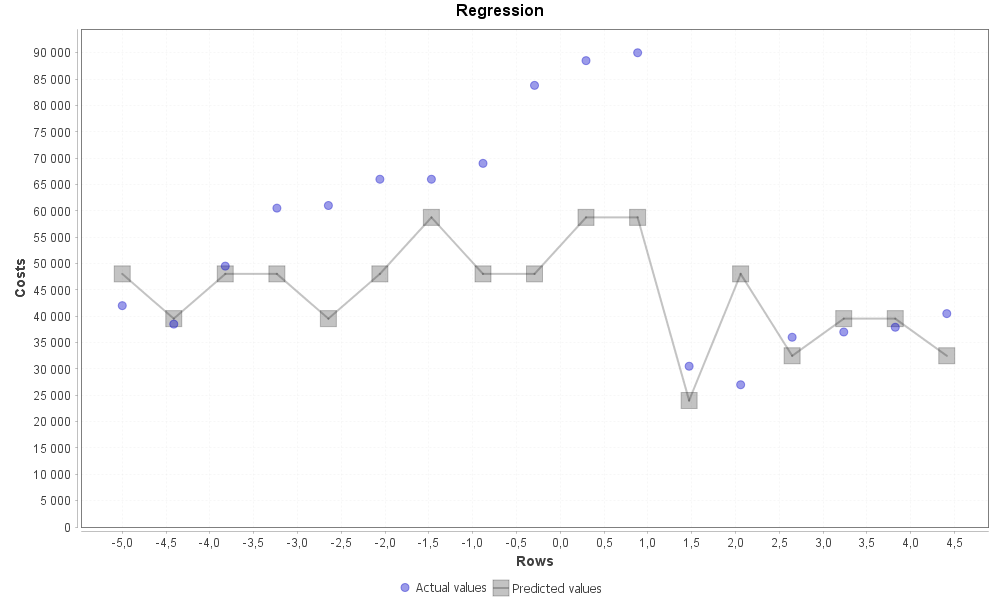

model: TrainableLinearRegressionModel = ammonite.$sess.cmd35$Helper$TrainableLinearRegressionModel@46f2f753
a: Double = -5.0
b: Double = 5.0
h: Double = 0.5882352941176471
i: Int = 17
dataset: XYSeriesCollection = org.jfree.data.xy.XYSeriesCollection@fc6f90b0
series1: XYSeries = org.jfree.data.xy.XYSeries@97e543d7
series2: XYSeries = org.jfree.data.xy.XYSeries@c48c7897
chart: JFreeChart = org.jfree.chart.JFreeChart@29c05b6e

In [65]:
val model = TrainableLinearRegressionModel(0.0)
  .addCategoricalFeature(col("driveway"), Map("yes" -> 1.0, "no" -> 0.0))
  .addScalarFeature(col("bedrooms"))
  .addCategoricalFeature(col("garage"), Map("yes" -> 1.0, "no" -> 0.0))
  .addScalarFeature(col("bathrooms"))
  .addScaledFeature(col("lotsize"), 1e-4)
  .build()
  .fit(rows.toArray, col("price"), 1.0)

// Прогнозируем
val a = -5.0
val b = 5.0
val h = (b - a) / rows.length
var i = 0

val dataset = new XYSeriesCollection()

val series1 = new XYSeries("Actual values")
val series2 = new XYSeries("Predicted values")
rows.foreach { row => 
  val testRow = row.toVector
  val predicted = model.predict(testRow)
  val actual = testRow(col("price")).toDouble
  
  // println(f"Predicted price: ${predicted}")
  // println(f"Actual price:    ${actual}")

  val x = a + i * h
  series1.add(x, actual)
  series2.add(x, predicted)
  i = i + 1
}
dataset.addSeries(series1)
dataset.addSeries(series2)

val chart = ChartFactory.createXYLineChart(
  "Regression",
  "Rows",
  "Costs",
  dataset,
  PlotOrientation.VERTICAL,
  true,   // legend
  true,   // tooltips
  false   // URLs
)

display(chart,
  styles = Map(
    "Actual values"  -> SeriesStyle(color = new Color(0,0,200,100),      drawMode = DrawMode.PointsOnly, shape = circle(4)),
    "Predicted values"   -> SeriesStyle(color = new Color(0,0,0,60),       drawMode = DrawMode.LinesAndPoints,     shape = square(8)),
  )
)

Но увы, встречается проблема регуляризации, масштабирования и подбора начальных весов. Из-за этого параметр lotsize приходится масштабировать. А также замена некоторых ячеек нулями в корне неверна и требуется предварительная первичная обработка данных.

## Approximation with polinoms n

Требуется приблизить функцию вида:

$$
y(x) = \frac{1}{1+25x^2}
$$

С признаками:

$$
g(x,\theta) = \sum\limits_{j=0}^n \theta_j x^j
$$

Функция потерь такая же как и раньше:

$$
L(g(x,\theta), x) = (g(x,\theta) - y(x))^2
$$

Обучающая выборка:

$$
X^I = \{x_i=4(i-1)/(I-1)-2 \ | \ i=1\dots I \}
$$

Тестовая выборка:
$$
X^I = \{x_i=(i-0.5)/(I-1) - 2 \ | \ i=1\dots I-1\}
$$

Построить графики для n=0,1,10,40 I=50

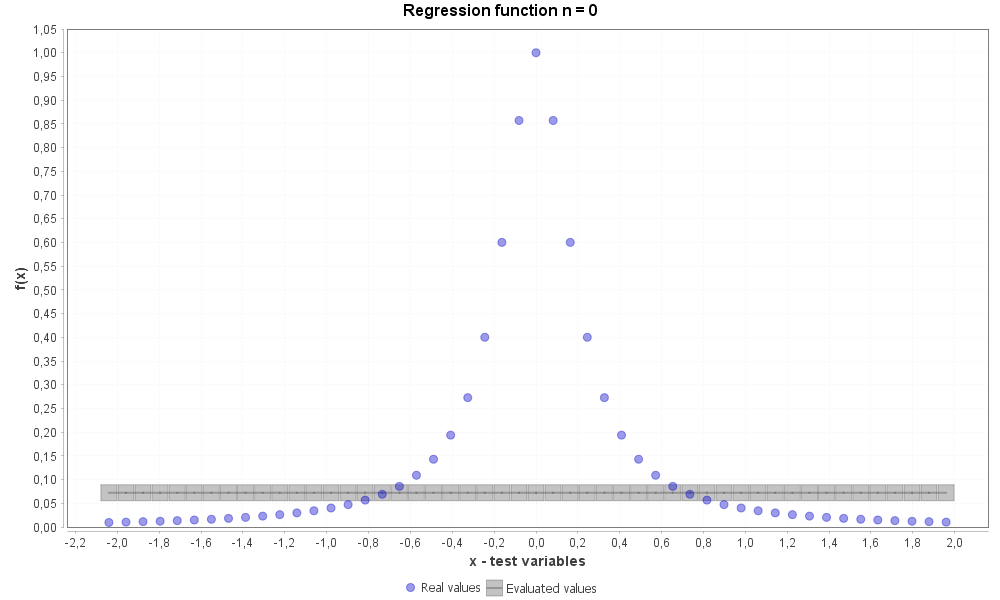

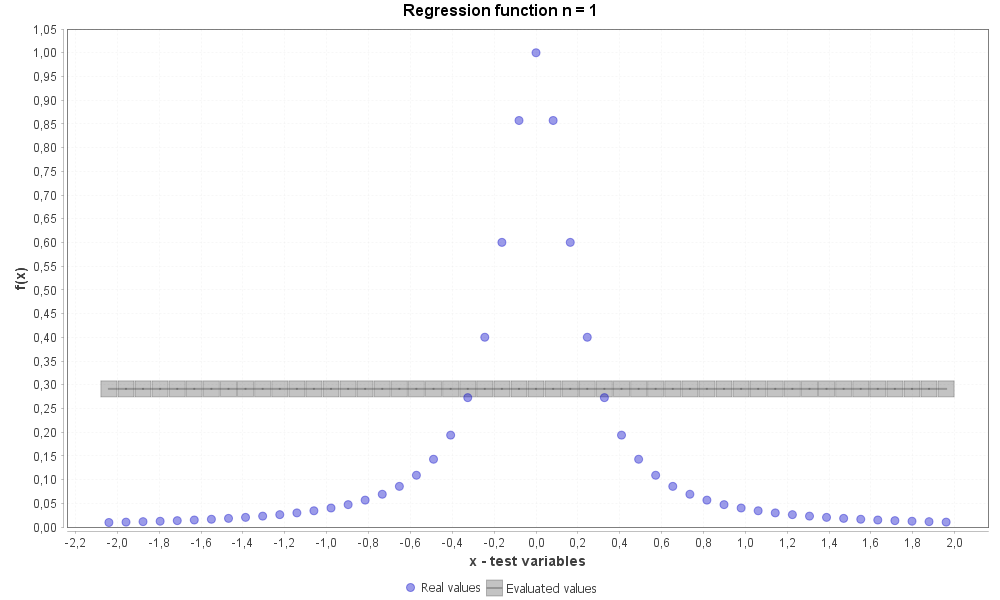

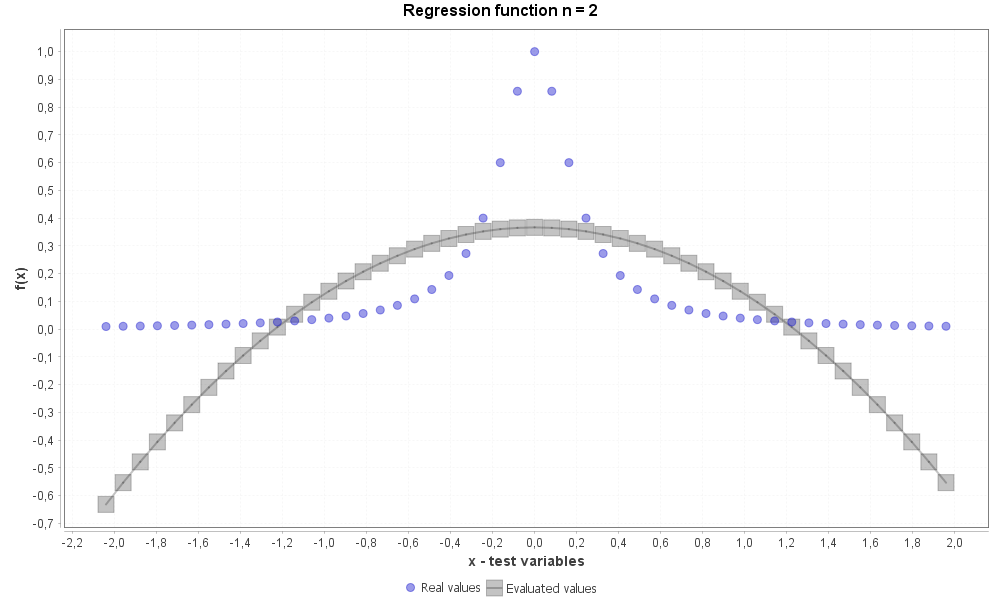

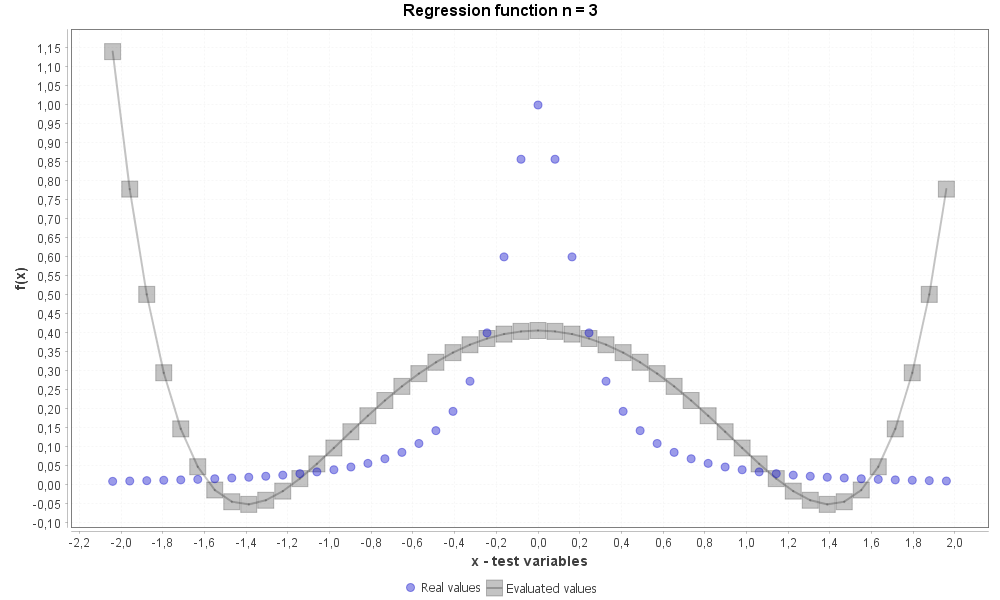

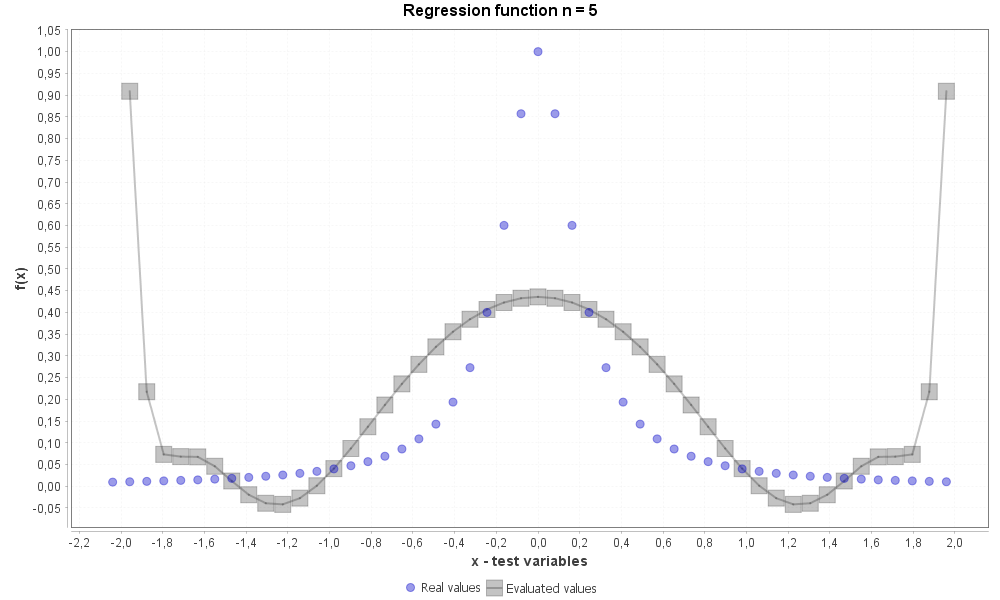

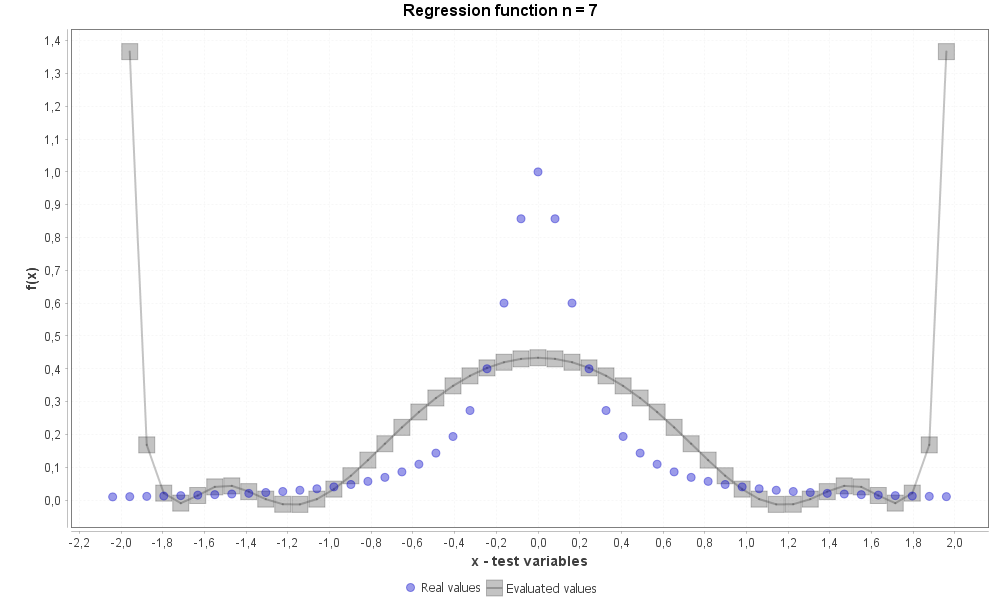

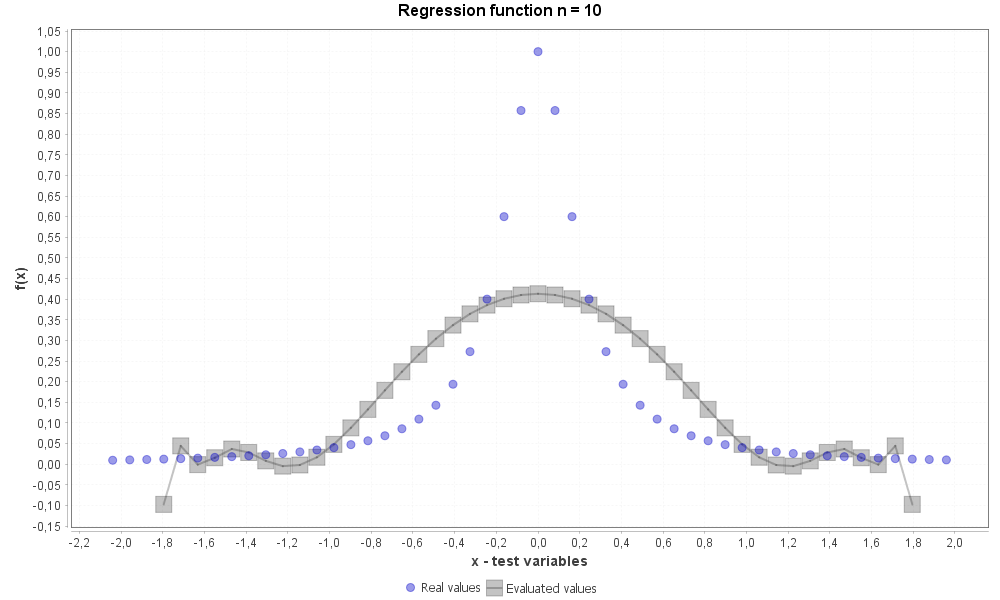

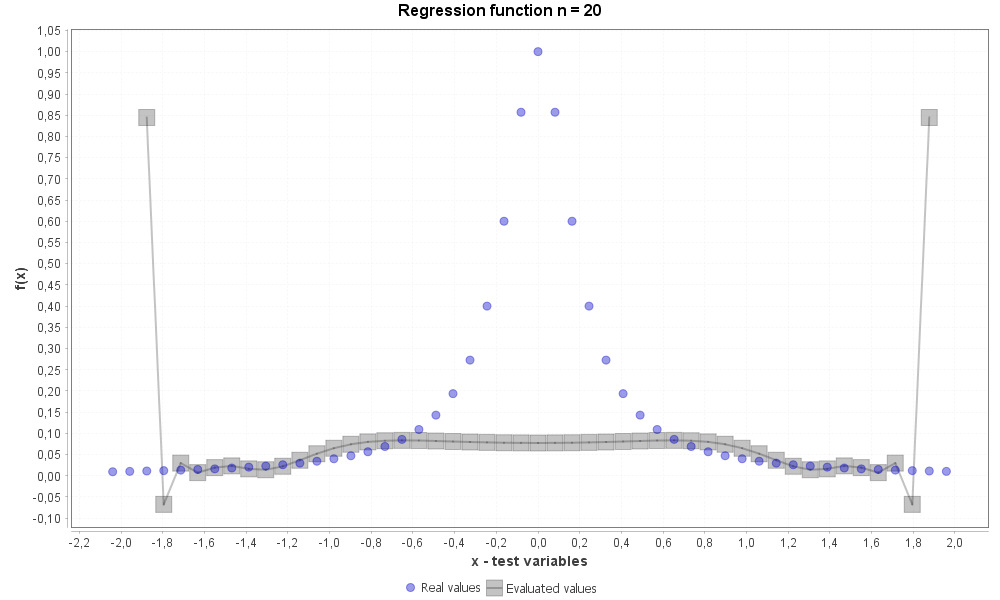

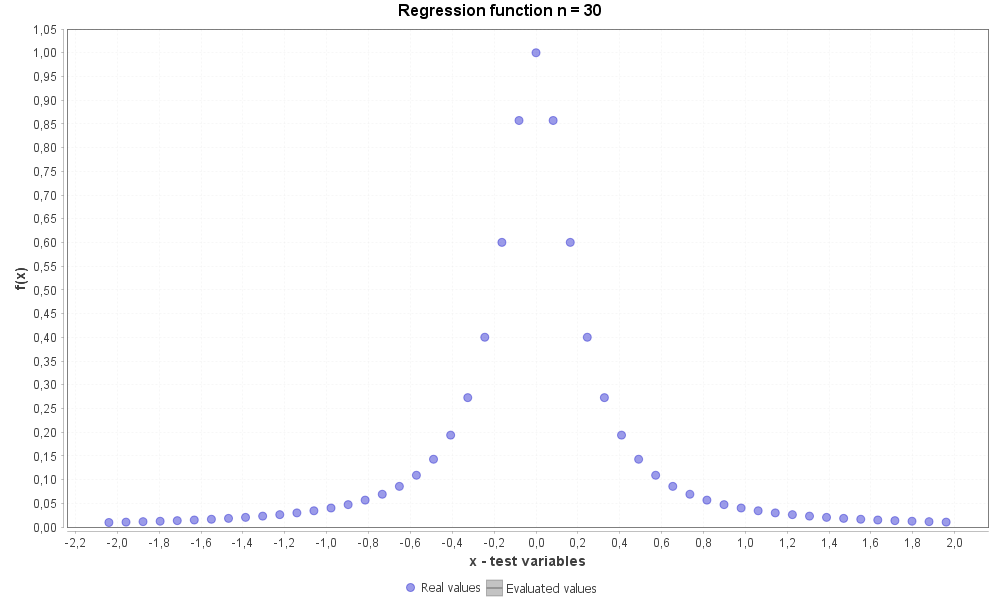

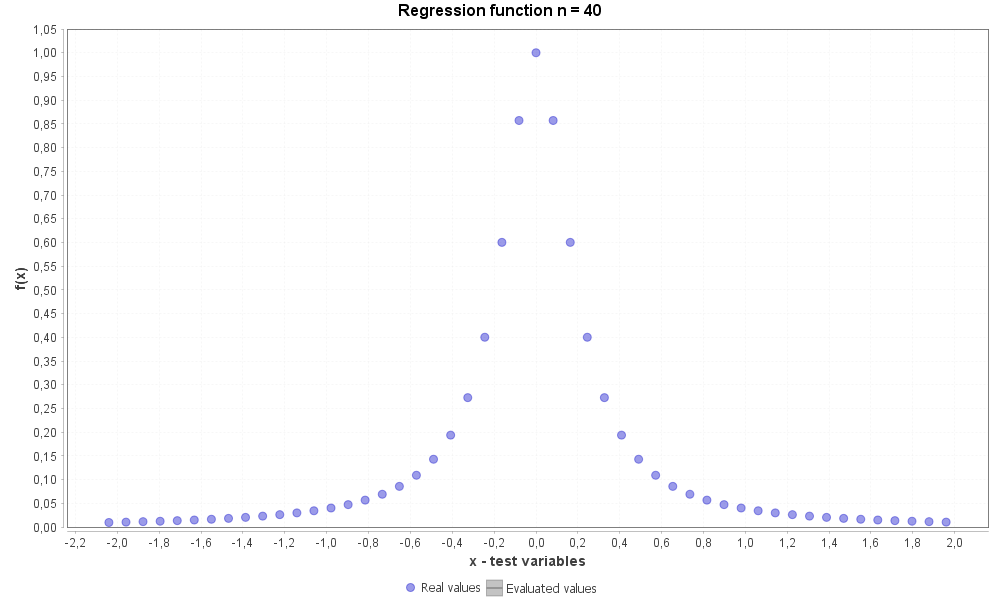

defined function show_approximation

In [ ]:
// n - как параметр - степень полинома 
def show_approximation(n: Int, values_filter: Double) = {
  val I = 50
  val xf = (i: Double) => 4.0 * (i - 1.0) / (I - 1) - 2.0
  val xt = (i: Double) => 4.0 * (i - 0.5) / (I - 1) - 2.0
  val fu = (x: Double) => 1.0 / (1.0 + 25.0 * x * x)

  // Plot
  val dataset = new XYSeriesCollection()
  val series1 = new XYSeries("Real values")
  val series2 = new XYSeries("Evaluated values")

  // Заполняем таблицу для обучения
  val fitTable: Vector[Vector[Double]] = 
    Vector.tabulate(I, n + 2) { (i, j) =>
      val x = xf(i)
      val fx = fu(x)
      if (j == 0) fx
      else math.pow(x, j)
    }
  
  val fitTableS = fitTable.map { s => s.map(_.toString).toArray }.toArray

  // Model
  var model = TrainableLinearRegressionModel(0)
  for (i <- 1 until n + 2) {
    model = model.addPowerFeature(i, i - 1)
  }
  model = model.build()
  model.fit(
    fitTableS,
    0,
    0.1,
    n
  )

  // Test table with real values and features
  val testTable: Vector[Vector[Double]] = 
    Vector.tabulate(I, n + 1) { (i, j) =>
      val x = xt(i)
      val fx = fu(x)
      if (j == 0) fx
      else math.pow(x, j)
    }

  // filling series
  for (i <- 0 until I) {
    val row = testTable(i)
    val x = xt(i)
    val actual = row(0)
    val p = model.predict(row.map(_.toString))

    series1.add(x, actual)
    if (p > -values_filter && p < values_filter)
      series2.add(x, p)
    // series2.add(xf(i), model.predict(fitTable(i).map(_.toString)))
  }

  dataset.addSeries(series1)
  dataset.addSeries(series2)

  val chart = ChartFactory.createXYLineChart(
    String.format(f"Regression function n = $n"),
    "x - test variables",
    "f(x)",
    dataset,
    PlotOrientation.VERTICAL,
    true,   // legend
    true,   // tooltips
    false   // URLs
  )

  display(chart,
    styles = Map(
      "Real values"  -> SeriesStyle(color = new Color(0,0,200,100),      drawMode = DrawMode.PointsOnly, shape = circle(4)),
      "Evaluated values"   -> SeriesStyle(color = new Color(0,0,0,60),       drawMode = DrawMode.LinesAndPoints,     shape = square(8)),
    )
  )
}

show_approximation(0, 1.0)
show_approximation(1, 2.0)
show_approximation(2, 2.0)
show_approximation(3, 2.0)
show_approximation(5, 2.0)
show_approximation(7, 2.0)
show_approximation(10, 2.0)
show_approximation(20, 2.0)
show_approximation(40, 1e6)

Здесь можно видеть, что точности вычислений становится недостаточно, присутствует выброс на последних тестовых значениях - следствие отсутствия работы с особо малыми значениями и погрешностями вычислений.

# Theme 2

Вероятностная постановка задачи даёт узнать, когда модель оказывается на пороге переобучения. То есть, узнать интервал, в котором достигается 95% вероятность совпадения входного результата с выходным. Это критически важно и может быть решением проблемы переобучения. Но это возможно только в байесовском подходе.

